In [1]:
import pandas as pd
import matplotlib.pyplot as pplot

In [2]:
data = pd.read_csv('archive/student-mat.csv')
see_cols = data.columns

In [3]:
'''
FEATURE SELECTIONS
NUMERICAL
[ "G1", "G2" ] # DONE cleaning
[ "absences", "Walc", "Dalc", "health", "goout", "failures", "studytime", "freetime" ]

CATEGORICAL
[ "activities", "internet", "romantic" ] # DONE converting(yes, no) from categorical to numerical (0, 1)
'''

'\nFEATURE SELECTIONS\nNUMERICAL\n[ "G1", "G2" ] # DONE cleaning\n[ "absences", "Walc", "Dalc", "health", "goout", "failures", "studytime", "freetime" ]\n\nCATEGORICAL\n[ "activities", "internet", "romantic" ] # DONE converting(yes, no) from categorical to numerical (0, 1)\n'

In [4]:
missing_values = data.isnull().sum() # no missing values shown
features = data[["G1", "G2", "absences", "Walc", "Dalc", "health", "goout", "failures", "studytime", "freetime", "activities", "internet", "romantic"]]

In [5]:
num_data_set = features.select_dtypes(include='number')
cat_data_set = features.select_dtypes(include='object')

new_cat_data_set = pd.get_dummies(cat_data_set, drop_first=True).astype(int) # just converted the categorical columns into numerical (from [ [yes] or [no] ] to [ [1] or [0] ])
final_data = pd.concat([num_data_set, new_cat_data_set], axis=1)

C:\Users\Clarise Tan\AppData\Local\Temp\ipykernel_3600\2053866630.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_data_set = features.select_dtypes(include='object')


Text(0.5, 1.0, 'BEFORE TAKING OUT: G1 VS G3')

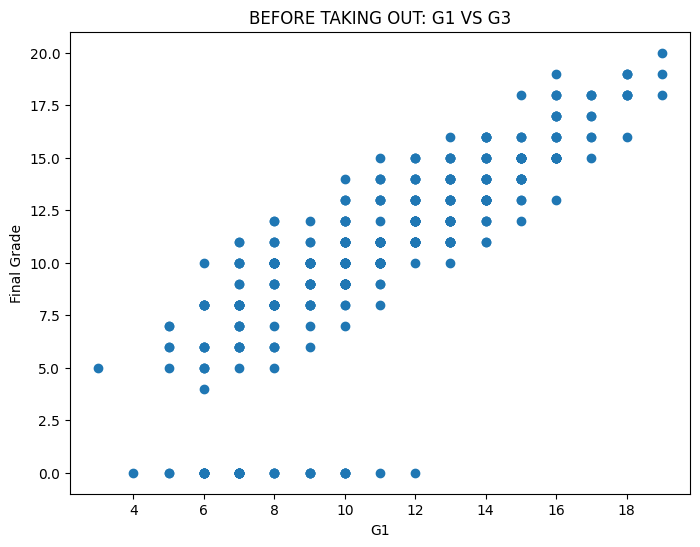

In [6]:
pplot.figure(figsize=(8, 6))
pplot.scatter(data["G1"], data["G3"])
pplot.xlabel("G1")
pplot.ylabel("Final Grade")
pplot.title("BEFORE TAKING OUT: G1 VS G3")

Text(0.5, 1.0, 'BEFORE TAKING OUT: G2 VS G3')

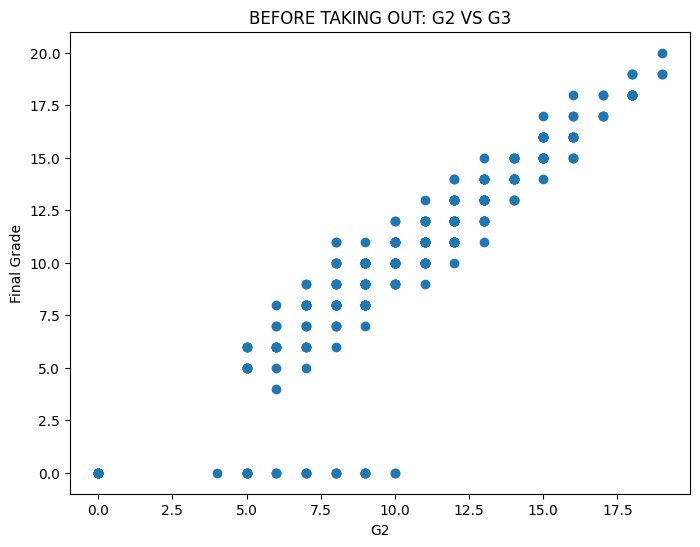

In [7]:
pplot.figure(figsize=(8, 6))
pplot.scatter(data["G2"], data["G3"])
pplot.xlabel("G2")
pplot.ylabel("Final Grade")
pplot.title("BEFORE TAKING OUT: G2 VS G3")

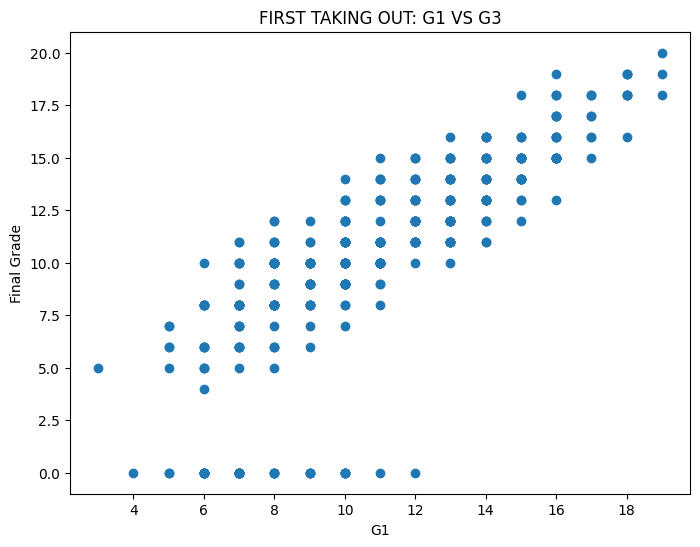

In [8]:
# removing outliers for G1 using IQR method
firstgr_Q1 = data["G1"].quantile(0.25)
firstgr_Q3 = data["G1"].quantile(0.75)
firstgr_IQR = firstgr_Q3 - firstgr_Q1

firstgr_lower = firstgr_Q1 - 1.5 * firstgr_IQR
firstgr_upper = firstgr_Q3 + 1.5 * firstgr_IQR

firstgr_data = data[(data["G1"] >= firstgr_lower) & (data["G1"] <= firstgr_upper)]

pplot.figure(figsize=(8, 6))
pplot.scatter(firstgr_data["G1"], firstgr_data["G3"])
pplot.xlabel("G1")
pplot.ylabel("Final Grade")
pplot.title("FIRST TAKING OUT: G1 VS G3")
pplot.show()

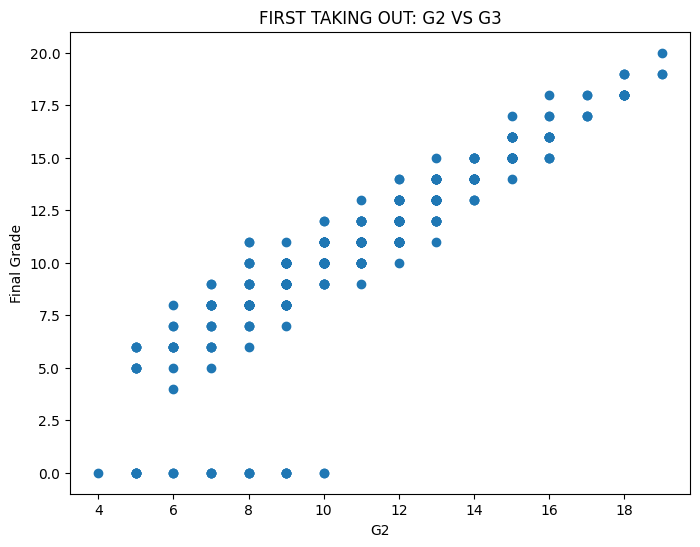

In [9]:
# removing outliers for G2 using IQR method
secondgr_Q1 = data["G2"].quantile(0.25)
secondgr_Q3 = data["G2"].quantile(0.75)
secondgr_IQR = secondgr_Q3 - secondgr_Q1

secondgr_lower = secondgr_Q1 - 1.5 * secondgr_IQR
secondgr_upper = secondgr_Q3 + 1.5 * secondgr_IQR

secondgr_data = data[(data["G2"] >= secondgr_lower) & (data["G2"] <= secondgr_upper)]

pplot.figure(figsize=(8, 6))
pplot.scatter(secondgr_data["G2"], secondgr_data["G3"])
pplot.xlabel("G2")
pplot.ylabel("Final Grade")
pplot.title("FIRST TAKING OUT: G2 VS G3")
pplot.show()

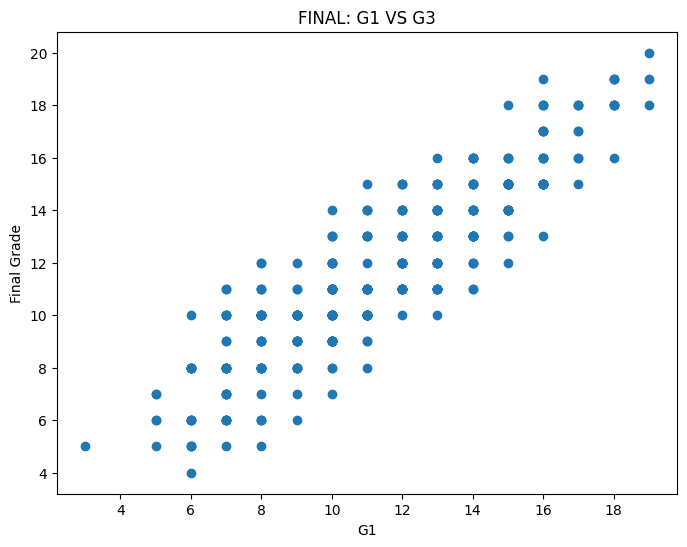

In [10]:
# removing outliers for G1 VS G3 using IQR method
finalgr1_Q1 = secondgr_data["G3"].quantile(0.25)
finalgr1_Q3 = secondgr_data["G3"].quantile(0.75)
finalgr1_IQR = finalgr1_Q3 - finalgr1_Q1

finalgr1_lower = finalgr1_Q1 - 1.5 * finalgr1_IQR
finalgr1_upper = finalgr1_Q3 + 1.5 * finalgr1_IQR

finalgr1_data = secondgr_data[(secondgr_data["G3"] >= finalgr1_lower) & (secondgr_data["G3"] <= finalgr1_upper)]
pplot.figure(figsize=(8, 6))
pplot.scatter(finalgr1_data["G1"], finalgr1_data["G3"])
pplot.xlabel("G1")
pplot.ylabel("Final Grade")
pplot.title("FINAL: G1 VS G3")
pplot.show()

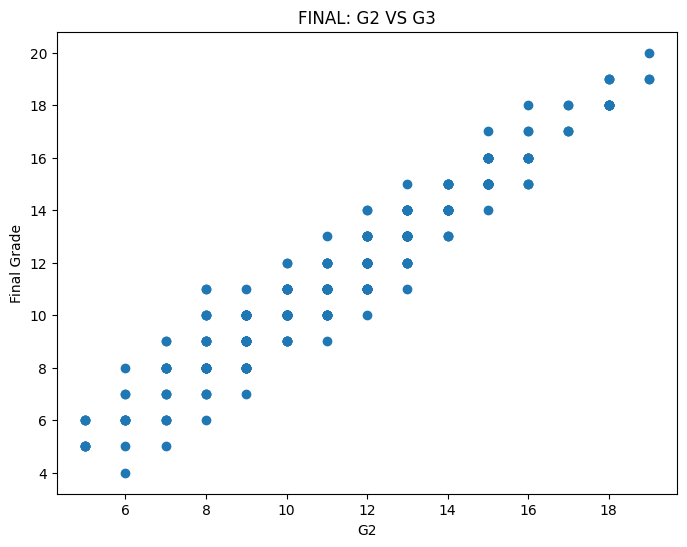

In [11]:
# removing outliers for G2 VS G3 using IQR method
finalgr2_Q1 = secondgr_data["G3"].quantile(0.25)
finalgr2_Q3 = secondgr_data["G3"].quantile(0.75)
finalgr2_IQR = finalgr2_Q3 - finalgr2_Q1

finalgr2_lower = finalgr2_Q1 - 1.5 * finalgr2_IQR
finalgr2_upper = finalgr2_Q3 + 1.5 * finalgr2_IQR

finalgr2_data = secondgr_data[(secondgr_data["G3"] >= finalgr2_lower) & (secondgr_data["G3"] <= finalgr2_upper)]
pplot.figure(figsize=(8, 6))
pplot.scatter(finalgr2_data["G2"], finalgr2_data["G3"])
pplot.xlabel("G2")
pplot.ylabel("Final Grade")
pplot.title("FINAL: G2 VS G3")
pplot.show()